# 单波形分批动态 STVMD 分析

读取一个 Instantel ASCII/TXT 文件，从 `Tran`、`Vert`、`Long` 中选择一个完整波形进行分批动态 STVMD。只需修改下一节的参数单元格。

## 1. 导入依赖

In [38]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy
from IPython.display import display

## 2. 手动参数

`WINDOW_LENGTH` 是短时时窗长度；`BATCH_WINDOWS` 只控制每批同时计算多少个窗口，不改变滑动步长。滑动步长固定为1。

In [39]:
# 只在这里修改输入文件、方向和STVMD参数。
INPUT_FILE = Path("15m.TXT")
DIRECTION = "Long"

K = 5
ALPHA = 50.0
WINDOW_LENGTH = 2048
TAU = 1e-5
TOL = 1e-5
MAX_ITERS = 300
BATCH_WINDOWS = 128

PLOT_MAX_HZ = 200.0
SAVE_OUTPUTS = True

print(
    f"file={INPUT_FILE}, direction={DIRECTION}, K={K}, "
    f"alpha={ALPHA}, window={WINDOW_LENGTH}, "
    f"batch={BATCH_WINDOWS}, max_iters={MAX_ITERS}"
)

file=15m.TXT, direction=Long, K=5, alpha=50.0, window=2048, batch=128, max_iters=300


## 3. 读取一个 TXT 波形

In [40]:
@dataclass(frozen=True)
class InstantelRecord:
    path: Path
    metadata: dict
    fs: float
    pretrigger_seconds: float
    data: np.ndarray


@dataclass(frozen=True)
class SingleWaveform:
    path: Path
    metadata: dict
    fs: float
    pretrigger_seconds: float
    direction: str
    time_s: np.ndarray
    values: np.ndarray


def _metadata_number(metadata, key):
    import re

    if key not in metadata:
        raise ValueError(f"缺少元数据字段: {key}")
    match = re.search(r"[-+]?\d+(?:\.\d+)?", metadata[key])
    if match is None:
        raise ValueError(f"无法解析元数据字段 {key}: {metadata[key]!r}")
    return float(match.group())


def load_instantel_txt(path):
    path = Path(path)
    if not path.is_file():
        raise FileNotFoundError(f"找不到输入文件: {path}")
    lines = path.read_text(
        encoding="utf-8-sig", errors="replace"
    ).splitlines()
    metadata = {}
    header_index = None
    for index, raw in enumerate(lines):
        stripped = raw.strip().strip('"')
        if all(name in stripped for name in ("Tran", "Vert", "Long")):
            header_index = index
            break
        if ":" in stripped:
            key, value = stripped.split(":", 1)
            metadata[key.strip()] = value.strip()
    if header_index is None:
        raise ValueError(f"{path.name}: 未找到 Tran/Vert/Long 数据表头")
    data = np.loadtxt(lines[header_index + 1 :], dtype=float)
    data = np.atleast_2d(data)
    if data.shape[1] != 3:
        raise ValueError(
            f"{path.name}: 期望3列数据，实际为{data.shape[1]}列"
        )
    if not np.isfinite(data).all():
        raise ValueError(f"{path.name}: 数据包含 NaN 或无穷值")
    fs = _metadata_number(metadata, "Sample Rate")
    pretrigger = abs(_metadata_number(metadata, "Pre-trigger Length"))
    if fs <= 0:
        raise ValueError(f"{path.name}: 采样率必须为正数")
    return InstantelRecord(
        path=path,
        metadata=metadata,
        fs=fs,
        pretrigger_seconds=pretrigger,
        data=data,
    )


def load_single_waveform(path, direction):
    direction_names = ("Tran", "Vert", "Long")
    if direction not in direction_names:
        raise ValueError(f"DIRECTION 必须为 {direction_names} 之一")
    record = load_instantel_txt(path)
    column = direction_names.index(direction)
    values = record.data[:, column].astype(float, copy=False)
    time_s = np.arange(values.size) / record.fs - record.pretrigger_seconds
    return SingleWaveform(
        path=record.path,
        metadata=record.metadata,
        fs=record.fs,
        pretrigger_seconds=record.pretrigger_seconds,
        direction=direction,
        time_s=time_s,
        values=values,
    )

## 4. 分批动态 STVMD

In [41]:
def validate_config(
    K, alpha, window_length, batch_windows, max_iters, tau, tol
):
    if not isinstance(K, (int, np.integer)) or K < 2:
        raise ValueError("K 必须为不小于2的整数")
    if not np.isfinite(alpha) or alpha <= 0:
        raise ValueError("ALPHA 必须为有限正数")
    if not isinstance(window_length, (int, np.integer)) or window_length < 2:
        raise ValueError("WINDOW_LENGTH 必须为不小于2的整数")
    if not isinstance(batch_windows, (int, np.integer)) or batch_windows < 1:
        raise ValueError("BATCH_WINDOWS 必须为正整数")
    if not isinstance(max_iters, (int, np.integer)) or max_iters < 2:
        raise ValueError("MAX_ITERS 必须为不小于2的整数")
    if not np.isfinite(tau) or tau <= 0:
        raise ValueError("TAU 必须为有限正数")
    if not np.isfinite(tol) or tol <= 0:
        raise ValueError("TOL 必须为有限正数")

def _pad_width(window_length):
    left = window_length // 2
    return left, window_length - 1 - left


def _window_batch(x_padded, window_length, start, stop, window):
    views = np.lib.stride_tricks.sliding_window_view(
        x_padded, window_shape=window_length, axis=1
    )
    segments = np.moveaxis(views[:, start:stop, :], 1, 2)
    return segments * window[None, :, None]


def _solve_dynamic_batch(f_hat, K, alpha, tau, tol, max_iters):
    channels, freq_bins, batch_n = f_hat.shape
    normalized_freq = np.arange(1, freq_bins + 1, dtype=float) / freq_bins
    u = np.zeros(
        (2, channels, freq_bins, K, batch_n), dtype=np.complex128
    )
    lagrange = np.zeros(
        (2, channels, freq_bins, batch_n), dtype=np.complex128
    )
    omega = np.zeros((2, K, batch_n), dtype=float)
    for mode in range(K):
        omega[0, mode, :] = mode / K

    active = np.ones(batch_n, dtype=bool)
    converged_windows = np.zeros(batch_n, dtype=bool)
    last_window_diff = np.full(batch_n, np.inf)
    final_diff = np.inf
    for iteration in range(max_iters):
        current = iteration % 2
        updated = (iteration + 1) % 2
        u[updated].fill(0)
        omega[updated] = omega[current]
        running_sum = np.sum(u[current], axis=2)
        for mode in range(K):
            running_sum -= u[current, :, :, mode, :]
            denominator = 1.0 + alpha * (
                normalized_freq[:, None] - omega[current, mode, :][None, :]
            ) ** 2
            u[updated, :, :, mode, :] = (
                f_hat - running_sum - lagrange[current] / 2.0
            ) / denominator[None, :, :]
            running_sum += u[updated, :, :, mode, :]
            if mode == 0:
                omega[updated, mode, :] = 0.0
            else:
                mode_power = np.sum(
                    np.abs(u[updated, :, :, mode, :]) ** 2, axis=0
                )
                denominator_power = np.sum(mode_power, axis=0)
                numerator_power = np.sum(
                    normalized_freq[:, None] * mode_power, axis=0
                )
                omega[updated, mode, :] = np.divide(
                    numerator_power,
                    denominator_power,
                    out=np.zeros_like(numerator_power),
                    where=denominator_power > np.finfo(float).eps,
                )
        lagrange[updated] = lagrange[current] + tau * (
            np.sum(u[updated], axis=2) - f_hat
        )
        inactive_columns = np.flatnonzero(~active)
        if inactive_columns.size:
            u[updated, :, :, :, inactive_columns] = u[
                current, :, :, :, inactive_columns
            ]
            omega[updated, :, inactive_columns] = omega[
                current, :, inactive_columns
            ]
            lagrange[updated, :, :, inactive_columns] = lagrange[
                current, :, :, inactive_columns
            ]
        window_diff = np.max(
            np.mean(np.abs(u[updated] - u[current]) ** 2, axis=(1, 2)),
            axis=0,
        )
        last_window_diff[active] = window_diff[active]
        if iteration >= 2:
            newly_converged = active & (window_diff < tol)
            converged_windows[newly_converged] = True
            active[newly_converged] = False
            if not np.any(active):
                break

    final_index = (iteration + 1) % 2
    u_final = u[final_index].copy()
    omega_final = omega[final_index].copy()
    for column in range(batch_n):
        order = np.argsort(omega_final[:, column])
        u_final[:, :, :, column] = (
            u_final[:, :, :, column][:, :, order].copy()
        )
        omega_final[:, column] = omega_final[order, column]
    final_diff = float(np.max(last_window_diff))
    return (
        u_final,
        omega_final,
        iteration + 1,
        bool(np.all(converged_windows)),
        final_diff,
    )


def run_dynamic_stvmd_batched(
    x,
    fs,
    K=4,
    alpha=50.0,
    window_length=64,
    tau=1e-5,
    tol=1e-9,
    max_iters=2000,
    batch_windows=256,
):
    x = np.asarray(x, dtype=float)
    if x.ndim != 2:
        raise ValueError("输入必须为 (通道, 时间) 二维数组")
    if not np.isfinite(x).all():
        raise ValueError("输入包含 NaN 或无穷值")
    if not np.isfinite(fs) or fs <= 0:
        raise ValueError("采样率必须为有限正数")
    validate_config(
        K, alpha, window_length, batch_windows, max_iters, tau, tol
    )
    channels, sample_n = x.shape
    if sample_n < window_length:
        raise ValueError("样本数不能小于 WINDOW_LENGTH")

    left, right = _pad_width(window_length)
    x_padded = np.pad(x, ((0, 0), (left, right)), mode="reflect")
    window = scipy.signal.windows.hamming(window_length, sym=False)
    freq_bins = window_length // 2 + 1
    modes_accum = np.zeros(
        (K, channels, sample_n + window_length - 1), dtype=float
    )
    norm = np.zeros(sample_n + window_length - 1, dtype=float)
    center_freq_hz = np.zeros((K, sample_n), dtype=float)
    mean_tf_power = np.zeros((freq_bins, sample_n), dtype=float)
    iterations = []
    convergence = []

    for start in range(0, sample_n, batch_windows):
        stop = min(sample_n, start + batch_windows)
        windowed = _window_batch(
            x_padded, window_length, start, stop, window
        )
        f_hat = scipy.fft.rfft(windowed, axis=1, workers=-1)
        mean_tf_power[:, start:stop] = np.mean(np.abs(f_hat) ** 2, axis=0)
        u_hat, omega, count, converged, diff = _solve_dynamic_batch(
            f_hat, K, alpha, tau, tol, max_iters
        )
        center_freq_hz[:, start:stop] = omega * (fs / 2.0)
        batch_modes = scipy.fft.irfft(
            u_hat, n=window_length, axis=1, workers=-1
        ).real
        for local_column, global_column in enumerate(range(start, stop)):
            target = slice(global_column, global_column + window_length)
            norm[target] += window ** 2
            for mode in range(K):
                modes_accum[mode, :, target] += (
                    batch_modes[:, :, mode, local_column] * window[None, :]
                )
        iterations.append(count)
        convergence.append((converged, diff))

    safe_norm = np.where(norm > np.finfo(float).eps, norm, 1.0)
    modes_full = modes_accum / safe_norm[None, None, :]
    modes = modes_full[:, :, left : left + sample_n]
    return {
        "modes": modes,
        "center_freq_hz": center_freq_hz,
        "mean_tf_power": mean_tf_power,
        "iterations": np.asarray(iterations, dtype=int),
        "converged": np.asarray([item[0] for item in convergence], dtype=bool),
        "final_diff": np.asarray(
            [item[1] for item in convergence], dtype=float
        ),
    }

## 5. 结果诊断

In [42]:
def power_to_db(power, floor_db=-100.0):
    power = np.asarray(power, dtype=float)
    peak = float(np.max(power))
    if not np.isfinite(peak) or peak <= 0:
        return np.full_like(power, floor_db)
    db = 10.0 * np.log10(
        np.maximum(power / peak, 10 ** (floor_db / 10))
    )
    return np.maximum(db, floor_db)


def _energy_band(freq_hz, power, low=0.05, high=0.95):
    power = np.maximum(np.asarray(power, dtype=float), 0.0)
    total = float(np.sum(power))
    if total <= np.finfo(float).eps:
        return np.array([0.0, 0.0])
    cumulative = np.cumsum(power) / total
    return np.array(
        [
            np.interp(low, cumulative, freq_hz),
            np.interp(high, cumulative, freq_hz),
        ]
    )


def summarize_stvmd_result(x, fs, raw_result):
    modes = raw_result["modes"]
    reconstruction = np.sum(modes, axis=0)
    denominator = np.linalg.norm(x, axis=1)
    nrmse = np.divide(
        np.linalg.norm(x - reconstruction, axis=1),
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > np.finfo(float).eps,
    )
    mode_energy = np.sum(modes ** 2, axis=2)
    channel_energy = np.sum(mode_energy, axis=0, keepdims=True)
    energy_fraction = np.divide(
        mode_energy,
        channel_energy,
        out=np.zeros_like(mode_energy),
        where=channel_energy > np.finfo(float).eps,
    )
    freq_hz = scipy.fft.rfftfreq(modes.shape[-1], d=1.0 / fs)
    bands = np.zeros((modes.shape[0], 2), dtype=float)
    mode_power = np.zeros((modes.shape[0], freq_hz.size), dtype=float)
    for mode in range(modes.shape[0]):
        spectra = scipy.fft.rfft(modes[mode], axis=1, workers=-1)
        mode_power[mode] = np.sum(np.abs(spectra) ** 2, axis=0)
        bands[mode] = _energy_band(freq_hz, mode_power[mode])
    result = dict(raw_result)
    result.update(
        {
            "reconstruction": reconstruction,
            "nrmse": nrmse,
            "energy_fraction": energy_fraction,
            "frequency_hz": freq_hz,
            "mode_power": mode_power,
            "frequency_bands_hz": bands,
        }
    )
    return result

## 6. 绘图与保存函数

In [43]:
def _mode_color(mode):
    return plt.get_cmap("tab10")(mode % 10)


def _frequency_extent(waveform, frequency_bins):
    return [
        waveform.time_s[0],
        waveform.time_s[-1],
        0.0,
        waveform.fs / 2.0,
    ]


def _limit_frequency_axis(axis, plot_max_hz, fs):
    axis.set_ylim(0.0, min(float(plot_max_hz), fs / 2.0))
    axis.set_ylabel("Frequency (Hz)")


def plot_input_and_tf(waveform, result, plot_max_hz):
    fig, axes = plt.subplots(
        1, 2, figsize=(12, 4.2), constrained_layout=True
    )
    axes[0].plot(waveform.time_s, waveform.values, lw=0.8)
    axes[0].axvline(0, color="black", ls="--", lw=0.8)
    axes[0].set(
        xlabel="Time (s)",
        ylabel="Velocity (mm/s)",
        title=f"{waveform.path.name}: {waveform.direction}",
    )
    image = axes[1].imshow(
        power_to_db(result["mean_tf_power"]),
        origin="lower",
        aspect="auto",
        extent=_frequency_extent(
            waveform, result["mean_tf_power"].shape[0]
        ),
        cmap="viridis",
        vmin=-80,
        vmax=0,
    )
    _limit_frequency_axis(axes[1], plot_max_hz, waveform.fs)
    axes[1].set(xlabel="Time (s)", title="Time-frequency power")
    fig.colorbar(image, ax=axes[1], label="Relative power (dB)")
    return fig


def plot_modes(waveform, result):
    modes = result["modes"][:, 0, :]
    fig, axes = plt.subplots(
        modes.shape[0],
        1,
        figsize=(11, max(4.0, 2.0 * modes.shape[0])),
        sharex=True,
        squeeze=False,
        constrained_layout=True,
    )
    for mode in range(modes.shape[0]):
        axis = axes[mode, 0]
        label = "Residual" if mode == 0 else f"Mode {mode}"
        axis.plot(
            waveform.time_s,
            modes[mode],
            color=_mode_color(mode),
            lw=0.75,
        )
        axis.axvline(0, color="black", ls="--", lw=0.6)
        axis.set_ylabel(f"{label}\nVelocity (mm/s)")
    axes[-1, 0].set_xlabel("Time (s)")
    fig.suptitle(
        f"{waveform.path.name} {waveform.direction}: dynamic STVMD modes"
    )
    return fig


def plot_if_and_reconstruction(waveform, result, plot_max_hz):
    mode_n = result["modes"].shape[0]
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(11, 8.5),
        gridspec_kw={"height_ratios": (1.2, 1.2, 0.8)},
        constrained_layout=True,
    )
    for mode in range(1, mode_n):
        axes[0].plot(
            waveform.time_s,
            result["center_freq_hz"][mode],
            color=_mode_color(mode),
            lw=1.0,
            label=f"Mode {mode}",
        )
    axes[0].axvline(0, color="black", ls="--", lw=0.7)
    axes[0].set(
        xlabel="Time (s)",
        ylabel="Frequency (Hz)",
        title="Instantaneous center frequencies",
        ylim=(0.0, min(float(plot_max_hz), waveform.fs / 2.0)),
    )
    axes[0].legend(frameon=False, ncol=max(1, mode_n - 1))

    axes[1].plot(
        waveform.time_s,
        waveform.values,
        color="#64748b",
        lw=0.8,
        label="Input",
    )
    axes[1].plot(
        waveform.time_s,
        result["reconstruction"][0],
        color="#D55E00",
        lw=0.7,
        label="Reconstruction",
    )
    axes[1].axvline(0, color="black", ls="--", lw=0.6)
    axes[1].set(
        xlabel="Time (s)",
        ylabel="Velocity (mm/s)",
        title=f"Reconstruction  NRMSE={result['nrmse'][0]:.3g}",
    )
    axes[1].legend(frameon=False)

    fractions = result["energy_fraction"][:, 0]
    bars = axes[2].bar(
        np.arange(mode_n),
        fractions,
        color=[_mode_color(mode) for mode in range(mode_n)],
    )
    axes[2].set(
        xlabel="Component",
        ylabel="Energy fraction",
        title="Mode energy fraction",
    )
    axes[2].set_xticks(
        np.arange(mode_n),
        ["Residual"] + [f"Mode {mode}" for mode in range(1, mode_n)],
    )
    axes[2].bar_label(bars, fmt="%.3f", fontsize=8)
    return fig


def plot_spectrum_if_mapping(waveform, result, plot_max_hz):
    freq_hz = scipy.fft.rfftfreq(
        waveform.values.size, d=1.0 / waveform.fs
    )
    amplitude = np.abs(scipy.fft.rfft(waveform.values, workers=-1))
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5.2),
        gridspec_kw={"width_ratios": (1.0, 3.2)},
        sharey=True,
        constrained_layout=True,
    )
    axes[0].plot(amplitude, freq_hz, color="#475569", lw=0.8)
    axes[0].set(
        xlabel="Amplitude",
        ylabel="Frequency (Hz)",
        title="Fourier spectrum",
    )
    image = axes[1].imshow(
        power_to_db(result["mean_tf_power"]),
        origin="lower",
        aspect="auto",
        extent=_frequency_extent(
            waveform, result["mean_tf_power"].shape[0]
        ),
        cmap="viridis",
        vmin=-80,
        vmax=0,
    )
    for mode in range(1, result["modes"].shape[0]):
        color = _mode_color(mode)
        low, high = result["frequency_bands_hz"][mode]
        axes[1].plot(
            waveform.time_s,
            result["center_freq_hz"][mode],
            color=color,
            lw=1.1,
            label=f"Mode {mode}: {low:.1f}-{high:.1f} Hz",
        )
        for boundary in (low, high):
            axes[0].axhline(boundary, color=color, ls="--", lw=0.8)
            axes[1].axhline(boundary, color=color, ls="--", lw=0.8)
    axes[1].axvline(0, color="white", ls=":", lw=0.8)
    axes[1].set(
        xlabel="Time (s)",
        title=f"{waveform.direction}: TF spectrum and IF tracks",
    )
    axes[1].legend(frameon=True, fontsize=8, loc="upper right")
    _limit_frequency_axis(axes[0], plot_max_hz, waveform.fs)
    _limit_frequency_axis(axes[1], plot_max_hz, waveform.fs)
    fig.colorbar(image, ax=axes[1], label="Relative power (dB)")
    return fig


def plot_single_waveform_results(waveform, result):
    return {
        "input_tf": plot_input_and_tf(waveform, result, PLOT_MAX_HZ),
        "modes": plot_modes(waveform, result),
        "if_reconstruction": plot_if_and_reconstruction(
            waveform, result, PLOT_MAX_HZ
        ),
        "spectrum_if_mapping": plot_spectrum_if_mapping(
            waveform, result, PLOT_MAX_HZ
        ),
    }

In [29]:
def analyze_single_waveform(waveform):
    x = waveform.values.reshape(1, -1)
    raw = run_dynamic_stvmd_batched(
        x,
        fs=waveform.fs,
        K=K,
        alpha=ALPHA,
        window_length=WINDOW_LENGTH,
        tau=TAU,
        tol=TOL,
        max_iters=MAX_ITERS,
        batch_windows=BATCH_WINDOWS,
    )
    return summarize_stvmd_result(x, waveform.fs, raw)


def save_single_waveform_results(output_dir, waveform, result, figures):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    prefix = waveform.direction.lower()
    for name, figure in figures.items():
        figure.savefig(
            output_dir / f"{prefix}_{name}.png",
            dpi=300,
            bbox_inches="tight",
        )
    np.savez_compressed(
        output_dir / "stvmd_single_waveform_results.npz",
        input_file=str(waveform.path),
        direction=waveform.direction,
        fs=waveform.fs,
        time_s=waveform.time_s,
        modes=result["modes"],
        center_freq_hz=result["center_freq_hz"],
        reconstruction=result["reconstruction"],
        nrmse=result["nrmse"],
        energy_fraction=result["energy_fraction"],
        frequency_bands_hz=result["frequency_bands_hz"],
    )

## 7. 运行完整波形分析

文件: D:\BaiduNetdiskDownload\vmd\Short-Time-Variational-Mode-Decomposition\15m.TXT
方向: Long
采样率: 4096.0 Hz
样本数: 23176
时间范围: (-0.5, 5.157958984375) s
时窗时间: 0.5 s
频率分辨率: 2.0 Hz


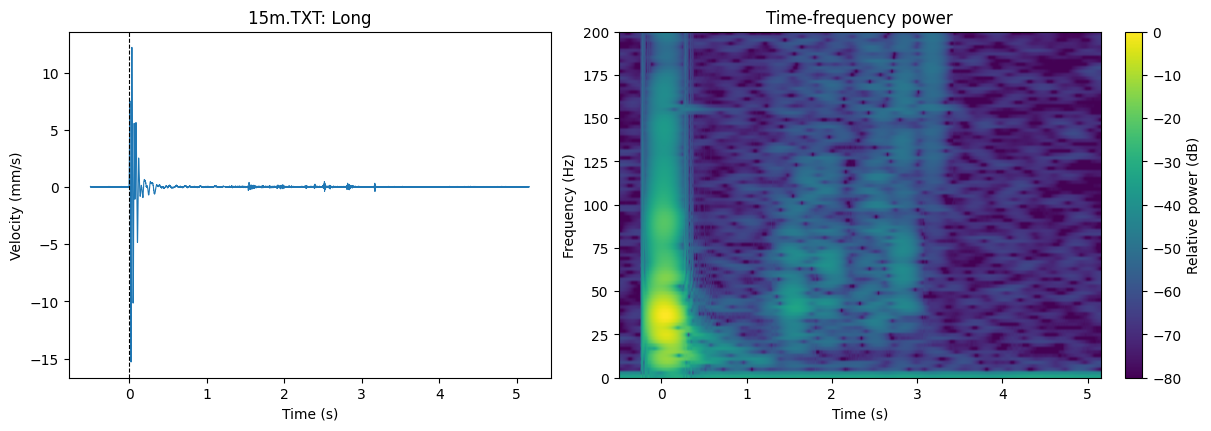

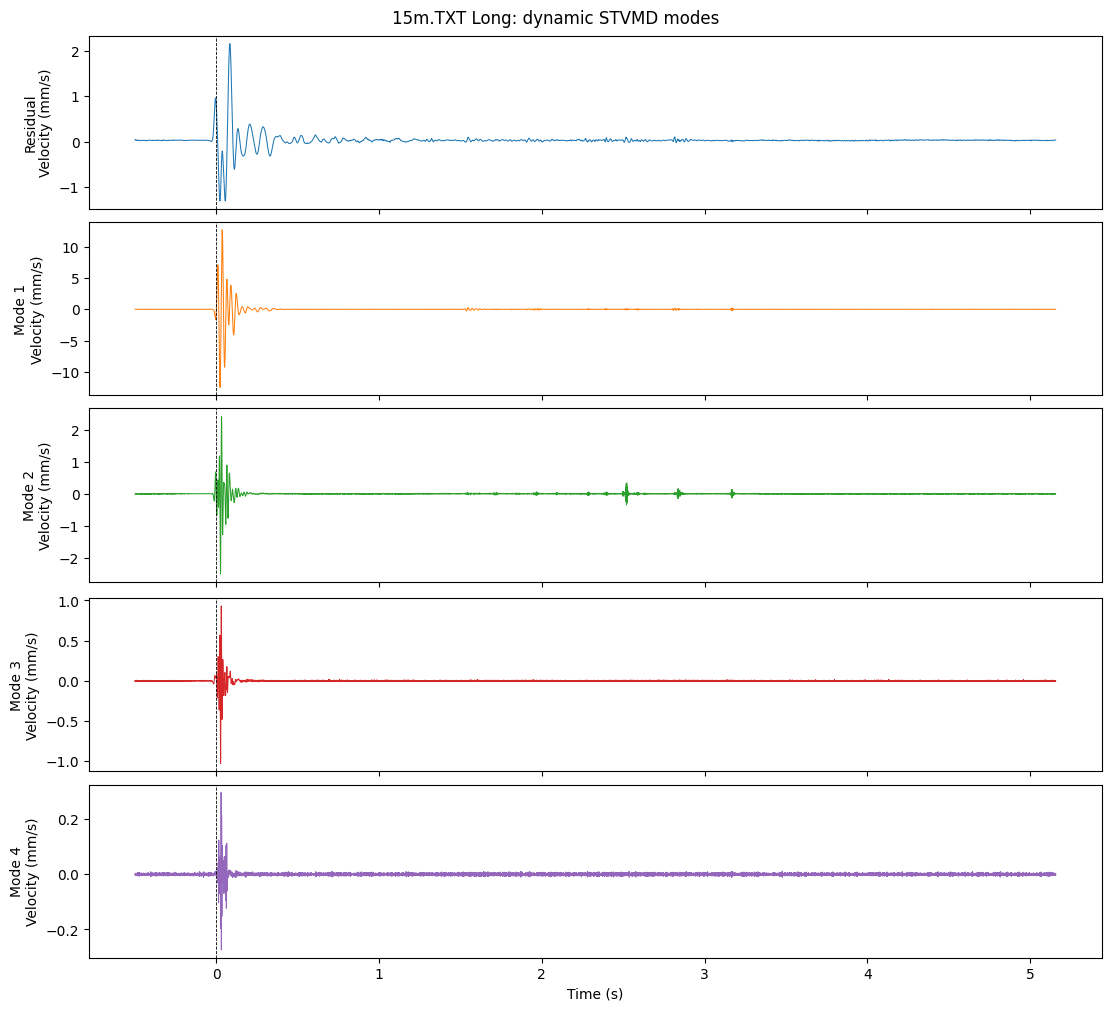

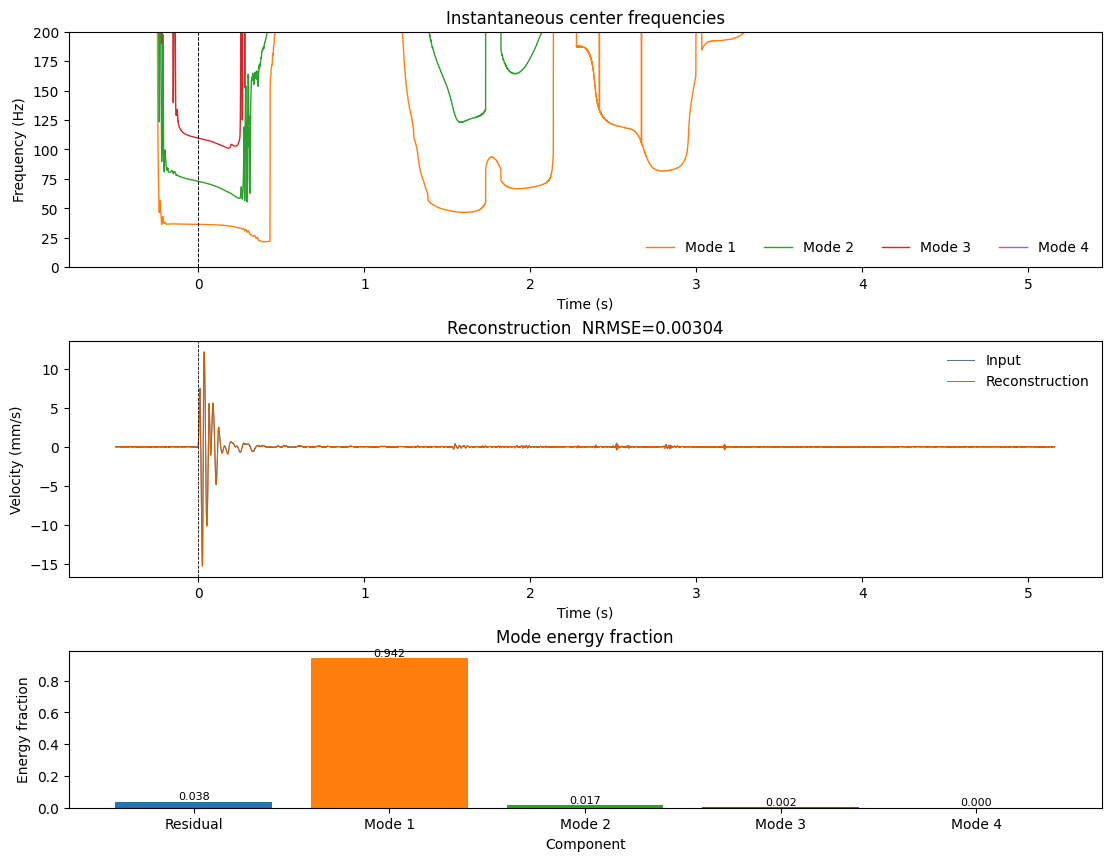

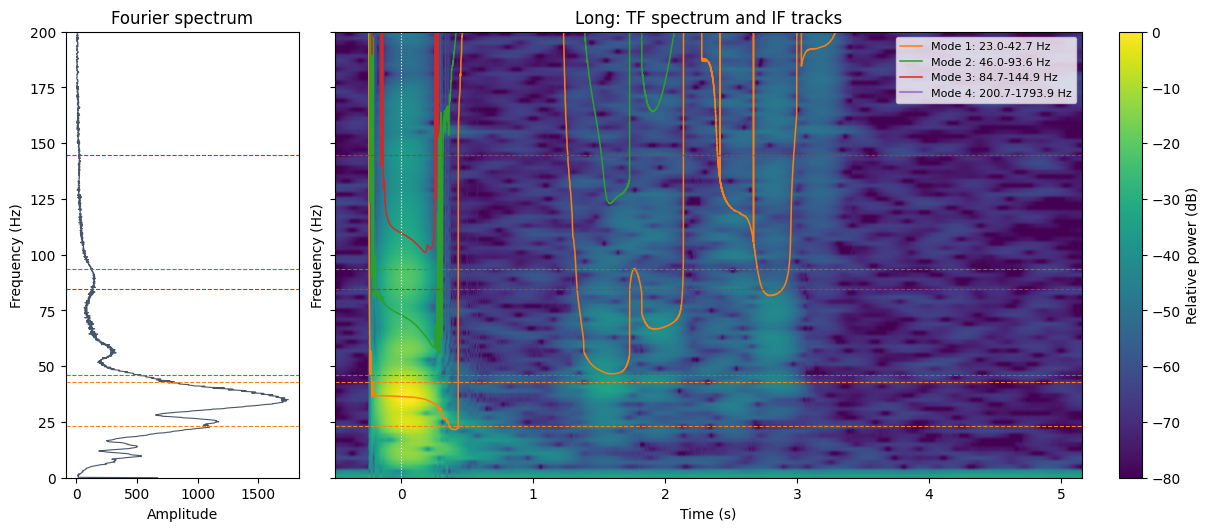

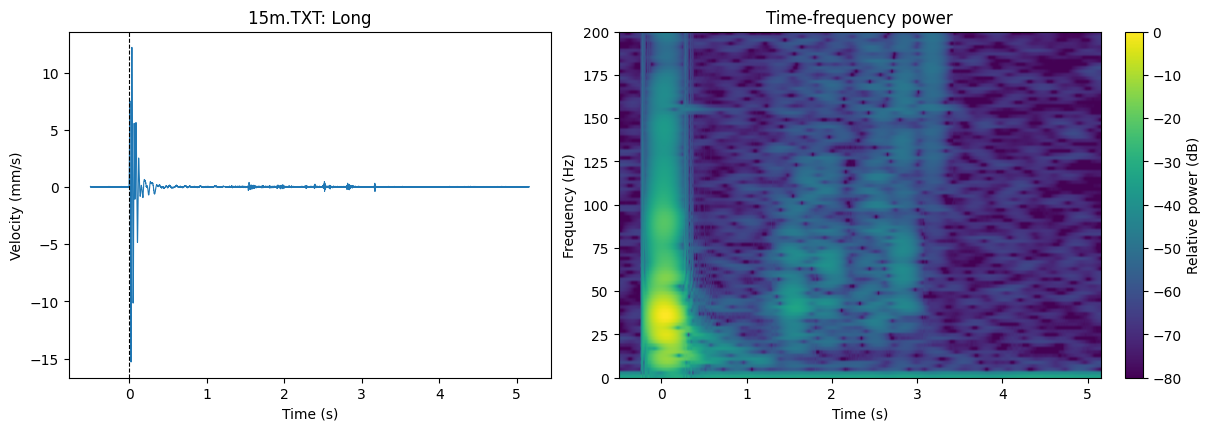

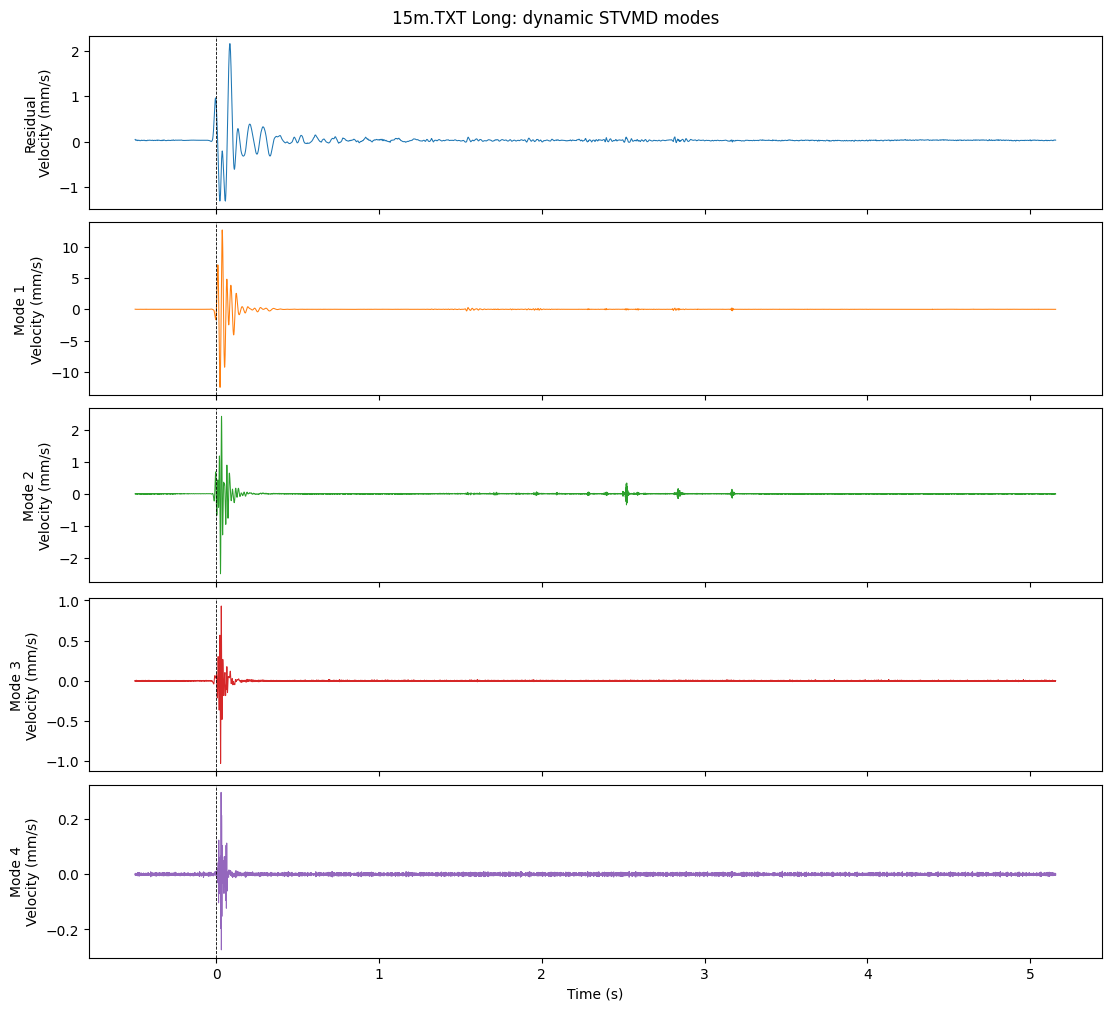

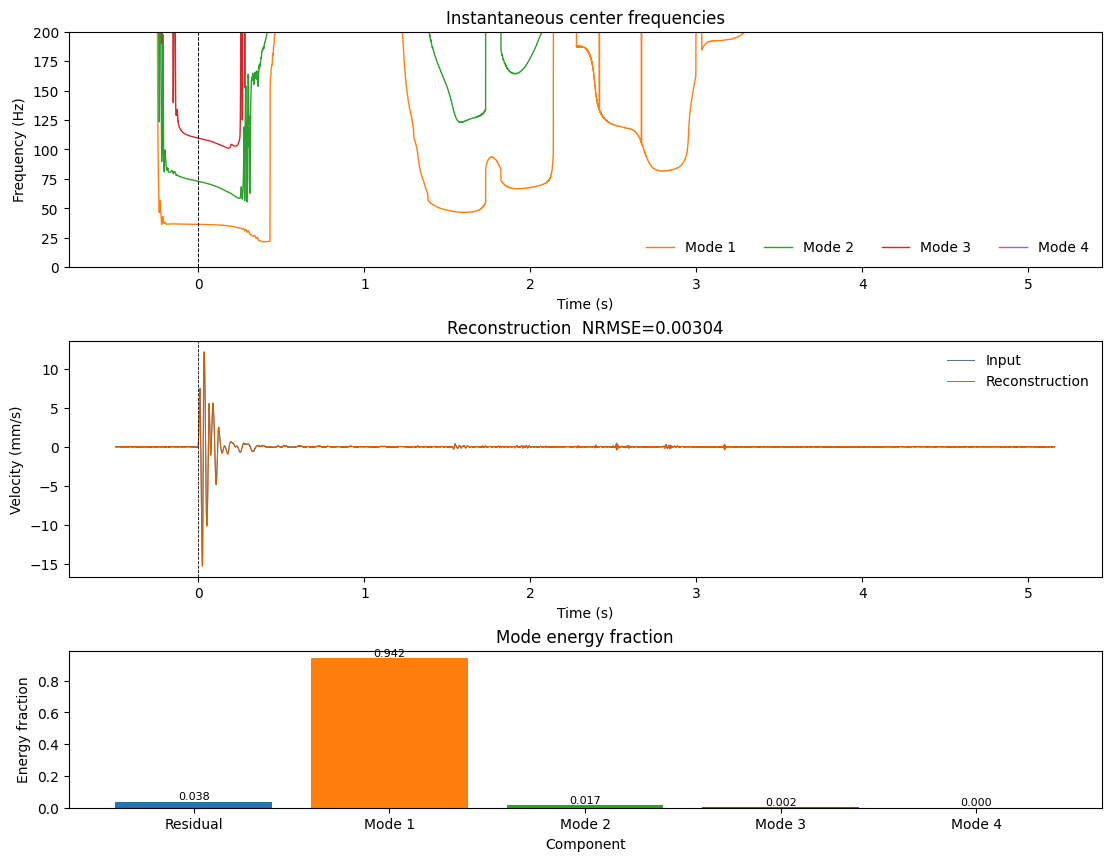

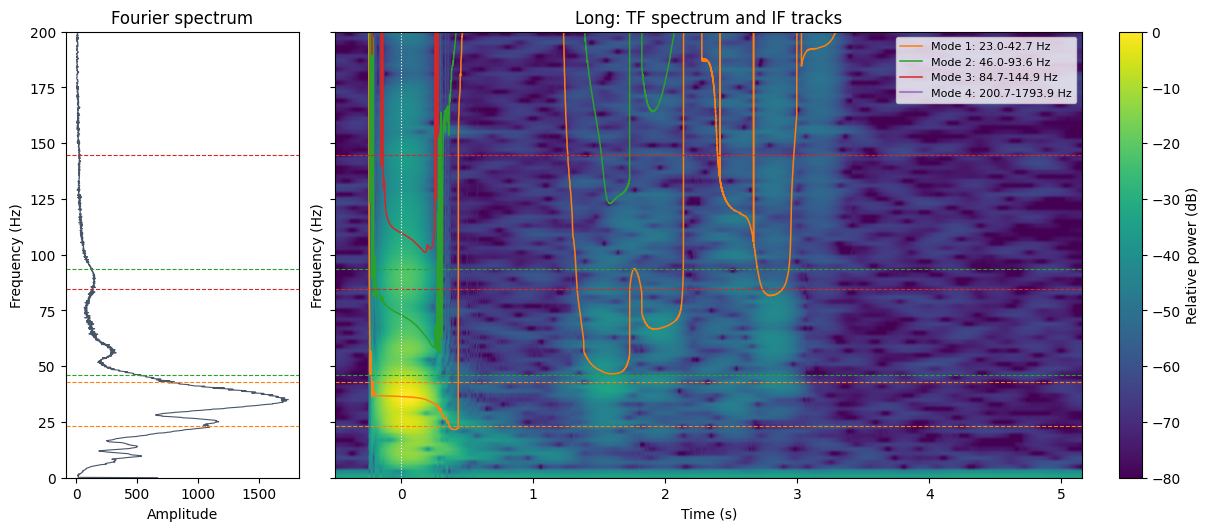

In [44]:
waveform = load_single_waveform(INPUT_FILE, DIRECTION)
print("文件:", waveform.path.resolve())
print("方向:", waveform.direction)
print("采样率:", waveform.fs, "Hz")
print("样本数:", waveform.values.size)
print(
    "时间范围:",
    (float(waveform.time_s[0]), float(waveform.time_s[-1])),
    "s",
)
print("时窗时间:", WINDOW_LENGTH / waveform.fs, "s")
print("频率分辨率:", waveform.fs / WINDOW_LENGTH, "Hz")

result = analyze_single_waveform(waveform)
figures = plot_single_waveform_results(waveform, result)
for figure in figures.values():
    display(figure)

## 8. 保存结果

In [ ]:
OUTPUT_DIR = Path("output/stvmd_single_waveform")
if SAVE_OUTPUTS:
    save_single_waveform_results(OUTPUT_DIR, waveform, result, figures)
    print(f"结果已保存到: {OUTPUT_DIR.resolve()}")
else:
    print("SAVE_OUTPUTS=False：未写出结果文件。")